In [4]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from shapely import wkt


Pre-processing for registered business 

What it is: A spatial map of 927 points, each representing an active, currently operating food business. It contains the business name, address, and exact GPS coordinates.

How to use it later (Siting the Hubs): You will not build a launch hub on every single restaurant. Instead, you will use Python libraries like SciKit-Learn to run a Spatial Clustering Algorithm (like K-Means or DBSCAN) on this dataset. This will mathematically identify the "center of gravity" where restaurant density is highest. Those cluster centers become the optimal coordinates for your rooftop "Launch Hubs."

In [2]:
# define the bounding box of

MIN_LON = -122.4450  # West boundary (around Twin Peaks/Noe Valley edge)
MAX_LON = -122.4080  # East boundary (around Potrero Hill/Mission edge)
MIN_LAT = 37.7480    # South boundary (around Cesar Chavez St)
MAX_LAT = 37.7680   # North boundary (around Market St/Van Ness Ave edge)

In [3]:
# load the csv using pandas

columns_to_load = [
    'DBA Name', 'Street Address', 'Business End Date', 
    'Location End Date', 'Administratively Closed', 
    'NAICS Code', 'Business Location'
]

df_biz = pd.read_csv('Registered_Business_Locations_-_San_Francisco_20260410.csv', usecols=columns_to_load, low_memory=False)


In [5]:
# select the relevant columns
df_biz = df_biz.dropna(subset=['Business Location']) 
if 'Latitude' in df_biz.columns and 'Longitude' in df_biz.columns:
    df_biz = df_biz.dropna(subset=['Latitude', 'Longitude'])

In [6]:
# filter for active businesses
df_biz = df_biz[
    (df_biz['Business End Date'].isna()) & 
    (df_biz['Location End Date'].isna()) &
    (df_biz['Administratively Closed'].isna())
]


In [7]:
# filter for Food Services
df_biz = df_biz[df_biz['NAICS Code'].astype(str).str.startswith('722')]


In [8]:
df_biz = df_biz.dropna(subset=['Business Location']) #drop with no GPS data

df_biz['geometry'] = df_biz['Business Location'].apply(wkt.loads)  # convert WKT to geometry

gdf_biz = gpd.GeoDataFrame(df_biz, geometry='geometry', crs='EPSG:4326')  # create GeoDataFrame

#apply bounding box
final_source_hubs = gdf_biz.cx[MIN_LON:MAX_LON, MIN_LAT:MAX_LAT]

final_source_hubs = final_source_hubs[['DBA Name', 'Street Address', 'NAICS Code', 'geometry']]


print(f"Success! Found {len(final_source_hubs)} potential Launch Hubs.")


Success! Found 927 potential Launch Hubs.


Pre-processing for Building FootPrints dataset:

What it is: A 3D topographical map of 15,559 polygons representing the physical footprint of every structure in the corridor over 2 meters tall, paired with its median height in meters (hgt_median_m).

How to use it later (Calculating Climb Cost): This is your drone's collision-avoidance and battery-drain dataset. Once you pick a Launch Hub (Point A) and a Kiosk (Point B), you will draw a straight geometric line between them. You will then write a script to check which building polygons intersect that line, and what their heights are. Your drone's minimum cruising altitude must clear the tallest building on that specific path, allowing you to calculate the exact vertical "Climb Cost" (battery consumption) for that specific delivery route.

In [9]:
columns_to_load = ['shape', 'hgt_median_m']
df_buildings = pd.read_csv('Building_Footprints_20260410.csv', usecols=columns_to_load, low_memory=False)


In [10]:
# drop with missing geometry
df_buildings = df_buildings.dropna(subset=['shape', 'hgt_median_m'])

df_buildings = df_buildings[df_buildings['hgt_median_m'] > 2.0] #only keep actual obstacles ( set 2m as threshold)
df_buildings['geometry'] = df_buildings['shape'].apply(wkt.loads) # convert WKT to geometry

gdf_buildings = gpd.GeoDataFrame(df_buildings, geometry='geometry', crs="EPSG:4326") 

#apply filter
final_buildings = gdf_buildings.cx[MIN_LON:MAX_LON, MIN_LAT:MAX_LAT]

# only keep height and geometry for obstacle analysis
final_buildings = final_buildings[['hgt_median_m', 'geometry']]

print(f"Success! Cropped down to {len(final_buildings)} 3D building obstacles in our target area.")

final_buildings.to_file('mission_noe_buildings.geojson', driver='GeoJSON')


Success! Cropped down to 15559 3D building obstacles in our target area.


Pre-processing for sf land use dataset
What it is: A map of 13,043 points (centroids) representing the exact middle of every residential property in the corridor, paired with the number of residential units (resunits) living there.

How to use it later (Siting the Kiosks): This dataset proves your market demand. Once you propose a location for a neighborhood drop-off Kiosk, you will use GeoPandas to draw a 400-meter circle around it (your 5-minute walking radius). You will then run a spatial join to count how many resunits fall inside that circle. This allows you to mathematically rank potential Kiosk sites by their "Residential Gravity" (e.g., Kiosk A serves 800 apartments, Kiosk B serves 2,100 apartments).

In [11]:
columns_to_load = ['the_geom', 'landuse', 'resunits']

df_landuse = pd.read_csv('San_Francisco_Land_Use_-_2023_20260410.csv', usecols=columns_to_load, low_memory=False)



In [12]:
# drop missing geometry

df_landuse = df_landuse.dropna(subset=['the_geom'])
df_landuse['resunits'] = pd.to_numeric(df_landuse['resunits'], errors='coerce').fillna(0)

# filter for residential areas with more than 0 residential units
df_landuse = df_landuse[df_landuse['resunits'] > 0]

df_landuse['geometry'] = df_landuse['the_geom'].apply(wkt.loads)
gdf_landuse = gpd.GeoDataFrame(df_landuse, geometry='geometry', crs="EPSG:4326")

#apply filter
final_sinks = gdf_landuse.cx[MIN_LON:MAX_LON, MIN_LAT:MAX_LAT]

#extra step: convert polygons to centroids
## Note: We use a projected CRS temporarily to calculate accurate centroids, then convert back to GPS
final_sinks = final_sinks.to_crs("EPSG:3857") # Web Mercator (meters)
final_sinks['geometry'] = final_sinks.geometry.centroid
final_sinks = final_sinks.to_crs("EPSG:4326") # Back to standard GPS (Lat/Lon)

#drop original text ggeometry column
final_sinks = final_sinks[['landuse', 'resunits', 'geometry']]
print(f"Success! Found {len(final_sinks)} residential properties in our target area.")

final_sinks.to_file('mission_noe_residential_sinks.geojson', driver='GeoJSON')


Success! Found 13043 residential properties in our target area.


About OSMnx
You cannot use straight lines to simulate an Uber or DoorDash driver. They are bound by the street grid, one-way streets, and intersections.

OSMnx allows you to pass in your exact same Bounding Box coordinates and download the literal "street graph" (nodes representing intersections, edges representing the roads between them) for the Mission-Noe corridor.

Let's look at your "Topographical Arbitrage."

The Drone: Flies 1.2 miles straight over Dolores Park.

The Car: Has to drive down 16th street, turn left on Dolores, navigate around the park, turn right on 20th, and wind up the hill.

OSMnx uses the NetworkX routing engine under the hood to calculate the actual drivable distance for the car (e.g., 2.4 miles). The delta between 1.2 miles and 2.4 miles is your "Arbitrage."

Once OSMnx downloads the street network, it usually includes the speed limits for those specific roads. You can write a script to say: "Calculate the shortest path between Restaurant A and Kiosk B, assuming the car travels at 15mph through residential zones and stops for 10 seconds at every intersection node."


Success! Downloaded a routing graph with 726 intersections and 2114 streets.


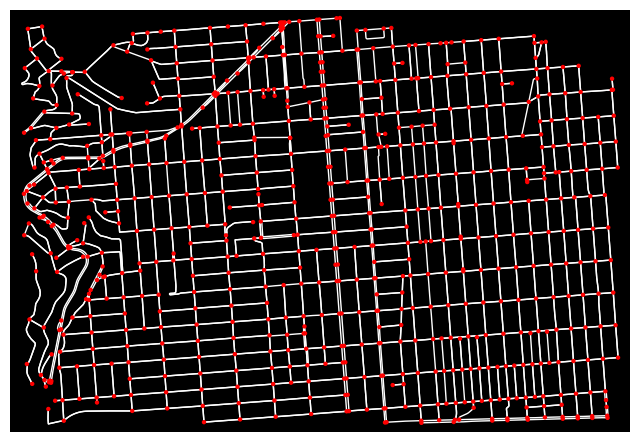

In [ ]:
import osmnx as ox
import matplotlib.pyplot as plt

# Note: OSMnx usually expects coordinates in this order: North, South, East, West
north = 37.7680
south = 37.7480
east = -122.4080
west = -122.4450

print("Downloading the street network from OpenStreetMap...")
# 2. Download the 'drive' network (excludes pedestrian-only paths)
# For older versions of OSMnx use: ox.graph_from_bbox(north, south, east, west, network_type='drive')
# For OSMnx v2.0+, use the bbox tuple:
try:
    G = ox.graph_from_bbox(bbox=(west, south, east, north), network_type='drive')
except TypeError:
    # Fallback for older OSMnx versions
    G = ox.graph_from_bbox(north, south, east, west, network_type='drive')

print(f"Success! Downloaded a routing graph with {len(G.nodes)} intersections and {len(G.edges)} streets.")

# 3. Visualize the ground grid you will be racing against
fig, ax = ox.plot_graph(G, node_size=10, node_color='red', edge_color='white', edge_linewidth=1, bgcolor='black')